# Graduating to a Real Dataset: Fashion-MNIST with an MLP

Notebooks 01-06 used a small synthetic 2D ring dataset where we could see the entire decision boundary on a single scatter plot. That is enough scope to study optimization choices in isolation, but it leaves out machinery that every real project needs.

This notebook keeps the architecture (still an MLP) and the methodology (early stopping on validation loss, multi-seed confirmation) but switches to **Fashion-MNIST** — 70,000 grayscale 28x28 images in 10 clothing classes. The point is not to push state-of-the-art accuracy; the point is to introduce the workflow that real datasets require:

- `Dataset` and `DataLoader` for mini-batching from disk-backed data,
- input normalization,
- a proper **three-way split** (train / validation / test),
- a test-set protocol: touched **once**, after model selection is finished.

Convolutional networks are a natural next step (notebook 08) — but first we want to see how far a plain MLP can take us, so the comparison later is fair.

## Learning goals

By the end of this notebook you should be able to explain:

1. why we keep a held-out test set separate from the validation set,
2. how `Dataset` + `DataLoader` replace the manual mini-batch loop from previous notebooks,
3. why we normalize the input (and how to compute or look up the mean/std),
4. how the early-stopping protocol from notebook 04-06 transfers unchanged to real-data training,
5. what a baseline MLP can achieve on Fashion-MNIST, and where its errors concentrate.

In [1]:
import math
import random
from pathlib import Path

import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, random_split
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt

seed = 11
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.set_num_threads(1)
try:
    torch.set_num_interop_threads(1)
except RuntimeError:
    pass

torch.set_default_dtype(torch.float32)

plt.rcParams.update({
    "figure.figsize": (7.4, 5.0),
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

# Pick the best available device. CPU is fine for this MLP, but MPS / CUDA will be faster.
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("PyTorch version:", torch.__version__)
print("Device:", device)

/Users/niksterg/miniconda3/envs/mlpytorch/lib/python3.11/site-packages/torchvision/io/image.py:14: UserWarning: Failed to load image Python extension: 'dlopen(/Users/niksterg/miniconda3/envs/mlpytorch/lib/python3.11/site-packages/torchvision/image.so, 0x0006): Library not loaded: @rpath/libjpeg.9.dylib
  Referenced from: <EB3FF92A-5EB1-3EE8-AF8B-5923C1265422> /Users/niksterg/miniconda3/envs/mlpytorch/lib/python3.11/site-packages/torchvision/image.so
  Reason: tried: '/Users/niksterg/miniconda3/envs/mlpytorch/lib/python3.11/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/Users/niksterg/miniconda3/envs/mlpytorch/lib/python3.11/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/Users/niksterg/miniconda3/envs/mlpytorch/lib/python3.11/lib-dynload/../../libjpeg.9.dylib' (no such file), '/Users/niksterg/miniconda3/envs/mlpytorch/bin/../lib/libjpeg.9.dylib' (no such file)'If you don't plan on using image functionality from `torchvision.io`, you can igno

PyTorch version: 2.5.1
Device: mps


## The three-way split, and why

In notebooks 04-06 we used a two-way split (train / validation) because we were just illustrating ideas. For any real evaluation we need three disjoint sets:

- **Train.** Used to fit the model weights. The optimizer sees this.
- **Validation.** Used for *model selection*: early stopping, hyperparameter choices, architecture comparisons. Looked at many times.
- **Test.** Used **once**, at the very end, to get an unbiased estimate of generalization.

If you tune anything on the test set, even informally ("let me peek and rerun with a different LR"), you have effectively turned it into a second validation set, and its accuracy number is no longer an unbiased estimate of how well the model will do on new data.

Fashion-MNIST ships with a 60,000 / 10,000 train/test split. We further carve 10,000 of the 60,000 training images into a validation set, leaving 50,000 for training.

In [2]:
DATA_DIR = Path("./data")
DATA_DIR.mkdir(exist_ok=True)

# Fashion-MNIST per-channel mean/std (well-known constants). We normalize so
# the optimizer sees input that has roughly mean 0 and unit variance.
FMNIST_MEAN = (0.2860,)
FMNIST_STD = (0.3530,)

transform = transforms.Compose([
    transforms.ToTensor(),  # uint8 in [0, 255] -> float32 in [0, 1], shape (1, 28, 28)
    transforms.Normalize(FMNIST_MEAN, FMNIST_STD),
])

full_train_set = torchvision.datasets.FashionMNIST(DATA_DIR, train=True, download=True, transform=transform)
test_set = torchvision.datasets.FashionMNIST(DATA_DIR, train=False, download=True, transform=transform)

VAL_SIZE = 10_000
train_size = len(full_train_set) - VAL_SIZE
split_generator = torch.Generator().manual_seed(42)
train_set, val_set = random_split(full_train_set, [train_size, VAL_SIZE], generator=split_generator)

CLASS_NAMES = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot",
]

print(f"Train: {len(train_set):>6d}")
print(f"Val:   {len(val_set):>6d}")
print(f"Test:  {len(test_set):>6d}")
print(f"Classes: {CLASS_NAMES}")

100.0%


Extracting data/FashionMNIST/raw/train-images-idx3-ubyte.gz to data/FashionMNIST/raw



100.0%


Extracting data/FashionMNIST/raw/train-labels-idx1-ubyte.gz to data/FashionMNIST/raw



100.0%


Extracting data/FashionMNIST/raw/t10k-images-idx3-ubyte.gz to data/FashionMNIST/raw



100.0%

Extracting data/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to data/FashionMNIST/raw

Train:  50000
Val:    10000
Test:   10000
Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


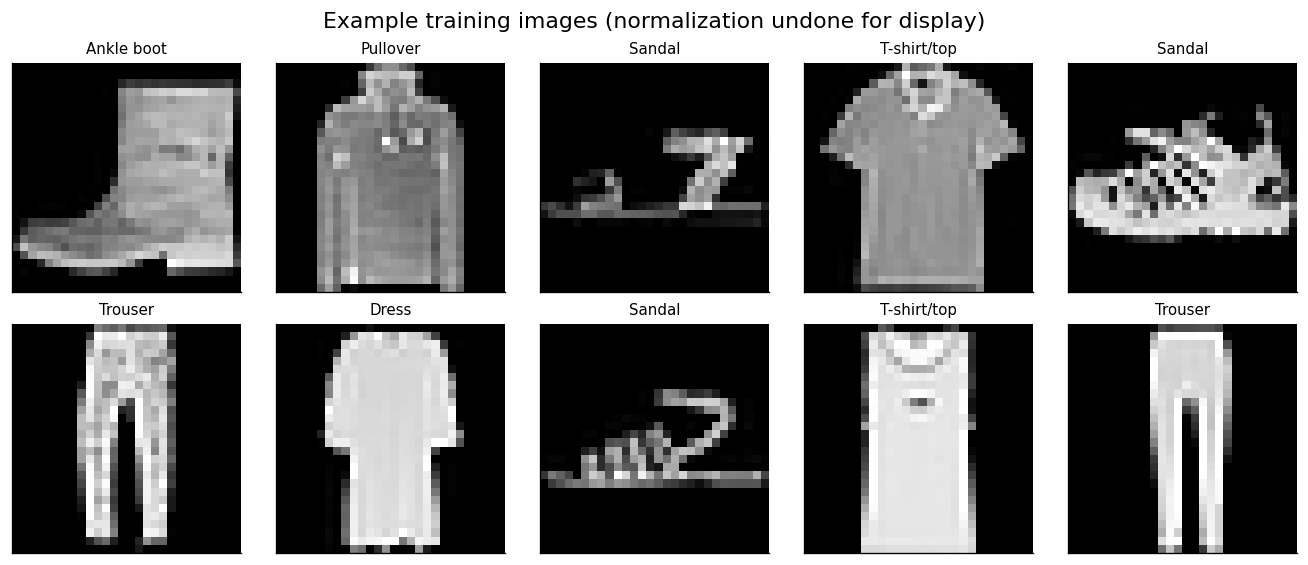

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(11, 4.6), constrained_layout=True)
shown = 0
for image, label in train_set:
    if shown >= 10:
        break
    ax = axes.flat[shown]
    # Undo normalization for display only
    img = image[0].numpy() * FMNIST_STD[0] + FMNIST_MEAN[0]
    ax.imshow(img, cmap="gray")
    ax.set_title(CLASS_NAMES[label], fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
    ax.grid(False)
    shown += 1
fig.suptitle("Example training images (normalization undone for display)")
plt.show()

## `DataLoader`: the mini-batch machinery

In notebooks 05 and 06 we wrote the mini-batch loop by hand:

```python
permutation = torch.randperm(n, generator=generator)
for start in range(0, n, batch_size):
    idx = permutation[start:start + batch_size]
    xb, yb = X_train[idx], y_train[idx]
```

That works when the whole dataset fits in memory as two tensors. For real datasets we use **`torch.utils.data.DataLoader`**, which takes a `Dataset` (any object with `__len__` and `__getitem__`) and gives us:

- shuffling each epoch,
- batching,
- optional parallel data loading via worker processes,
- a clean iterator protocol you can `for xb, yb in loader:` over.

The split objects we made above (`train_set`, `val_set`, `test_set`) are already `Dataset` instances, so we just wrap them.

In [4]:
BATCH_SIZE = 128

loader_generator = torch.Generator().manual_seed(2025)
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, generator=loader_generator)
val_loader   = DataLoader(val_set,   batch_size=512, shuffle=False)
test_loader  = DataLoader(test_set,  batch_size=512, shuffle=False)

# Sanity check a single batch
xb, yb = next(iter(train_loader))
print(f"xb shape: {tuple(xb.shape)}")
print(f"yb shape: {tuple(yb.shape)}")
print(f"xb dtype: {xb.dtype}")
print(f"xb mean/std (after normalization): {xb.mean().item():.3f} / {xb.std().item():.3f}")
print(f"yb sample: {yb[:8].tolist()}")

xb shape: (128, 1, 28, 28)
yb shape: (128,)
xb dtype: torch.float32
xb mean/std (after normalization): 0.029 / 1.024
yb sample: [4, 3, 4, 7, 1, 2, 4, 2]


## The MLP

Same architecture style as before, scaled up: input is 28 x 28 = 784 features (after a `Flatten`), one hidden block of 256 then 128 units with ReLU activations, and a 10-way linear classifier. We use **`CrossEntropyLoss`** because we have 10 classes; under the hood it combines a log-softmax with negative log-likelihood, so the model outputs raw logits (no softmax on the last layer).

Choice of ReLU instead of Tanh is deliberate: Tanh saturates for larger inputs and works less well as the network gets deeper or wider. ReLU is the modern default for fully-connected layers.

In [5]:
def make_mlp(seed, hidden=(256, 128), num_classes=10, input_dim=28*28):
    torch.manual_seed(seed)
    layers = [nn.Flatten()]
    in_dim = input_dim
    for h in hidden:
        layers += [nn.Linear(in_dim, h), nn.ReLU()]
        in_dim = h
    layers += [nn.Linear(in_dim, num_classes)]
    return nn.Sequential(*layers)

demo_model = make_mlp(seed=123)
n_params = sum(p.numel() for p in demo_model.parameters() if p.requires_grad)
print(demo_model)
print(f"\nTrainable parameters: {n_params:,}")

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=256, bias=True)
  (2): ReLU()
  (3): Linear(in_features=256, out_features=128, bias=True)
  (4): ReLU()
  (5): Linear(in_features=128, out_features=10, bias=True)
)

Trainable parameters: 235,146


## Training function (adapted for `DataLoader`)

The training loop is the same shape as in notebook 06 — train epoch, validate, early-stop on validation loss, restore best checkpoint — but with three changes for real-data scale:

1. iterate over a `DataLoader` instead of a hand-written index loop,
2. accumulate loss and accuracy across batches rather than recomputing them on the full dataset (the full validation set may not fit comfortably in memory all at once for larger datasets),
3. move tensors to the chosen `device` inside the loop.

In [6]:
def evaluate_loader(model, loader, loss_fn, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_n = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            total_loss += loss_fn(logits, yb).item() * xb.size(0)
            total_correct += (logits.argmax(-1) == yb).sum().item()
            total_n += xb.size(0)
    return total_loss / total_n, total_correct / total_n


def train_with_loaders(
    optimizer_factory,
    train_loader, val_loader,
    *,
    max_epochs=30,
    patience=5,
    min_delta=1e-4,
    model_seed=123,
    device=device,
    verbose=True,
):
    """Train an MLP with early stopping on validation loss. Returns model + history + best checkpoint."""
    model = make_mlp(model_seed).to(device)
    optimizer = optimizer_factory(model.parameters())
    loss_fn = nn.CrossEntropyLoss()

    history = {"epoch": [], "train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best = {"val_loss": float("inf"), "val_acc": None, "epoch": 0, "state_dict": None}
    epochs_no_improve = 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        running_loss = 0.0
        running_correct = 0
        running_n = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = loss_fn(logits, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * xb.size(0)
            running_correct += (logits.argmax(-1) == yb).sum().item()
            running_n += xb.size(0)
        train_loss = running_loss / running_n
        train_acc = running_correct / running_n

        val_loss, val_acc = evaluate_loader(model, val_loader, loss_fn, device)

        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if val_loss < best["val_loss"] - min_delta:
            best.update({
                "val_loss": val_loss, "val_acc": val_acc, "epoch": epoch,
                "state_dict": {k: v.detach().cpu().clone() for k, v in model.state_dict().items()},
            })
            epochs_no_improve = 0
            marker = "*"
        else:
            epochs_no_improve += 1
            marker = " "

        if verbose:
            print(f"epoch {epoch:3d} {marker} | train loss {train_loss:.3f} acc {train_acc:.3f} | val loss {val_loss:.3f} acc {val_acc:.3f}")

        if epochs_no_improve >= patience:
            if verbose:
                print(f"Early stopping at epoch {epoch} (no val improvement for {patience} epochs)")
            break

    if best["state_dict"] is not None:
        model.load_state_dict(best["state_dict"])
    return model, history, best

## Baseline training run

We use the optimizer that worked well in notebooks 05 and 06: **AdamW** at `lr=1e-3` (the standard default — `lr=0.03` is too aggressive for a real-data network with this many parameters). Early stopping with `patience=5` on a `max_epochs=30` budget.

In [7]:
def adamw_factory(lr, weight_decay=0.01):
    return lambda params: torch.optim.AdamW(params, lr=lr, weight_decay=weight_decay)

model, history, best = train_with_loaders(
    adamw_factory(lr=1e-3),
    train_loader, val_loader,
    max_epochs=30, patience=5,
    model_seed=123,
)

print()
print(f"Best epoch:        {best['epoch']}")
print(f"Best val loss:     {best['val_loss']:.4f}")
print(f"Best val accuracy: {best['val_acc']:.4f}")

epoch   1 * | train loss 0.506 acc 0.817 | val loss 0.396 acc 0.853
epoch   2 * | train loss 0.359 acc 0.867 | val loss 0.353 acc 0.869
epoch   3 * | train loss 0.323 acc 0.880 | val loss 0.343 acc 0.874
epoch   4 * | train loss 0.295 acc 0.890 | val loss 0.321 acc 0.882
epoch   5 * | train loss 0.274 acc 0.897 | val loss 0.320 acc 0.885
epoch   6 * | train loss 0.257 acc 0.903 | val loss 0.319 acc 0.884
epoch   7 * | train loss 0.241 acc 0.910 | val loss 0.314 acc 0.888
epoch   8 * | train loss 0.230 acc 0.913 | val loss 0.304 acc 0.893
epoch   9   | train loss 0.218 acc 0.918 | val loss 0.308 acc 0.891
epoch  10   | train loss 0.204 acc 0.923 | val loss 0.316 acc 0.891
epoch  11   | train loss 0.195 acc 0.926 | val loss 0.322 acc 0.891
epoch  12   | train loss 0.181 acc 0.931 | val loss 0.311 acc 0.893
epoch  13   | train loss 0.175 acc 0.934 | val loss 0.350 acc 0.887
Early stopping at epoch 13 (no val improvement for 5 epochs)

Best epoch:        8
Best val loss:     0.3041
Best va

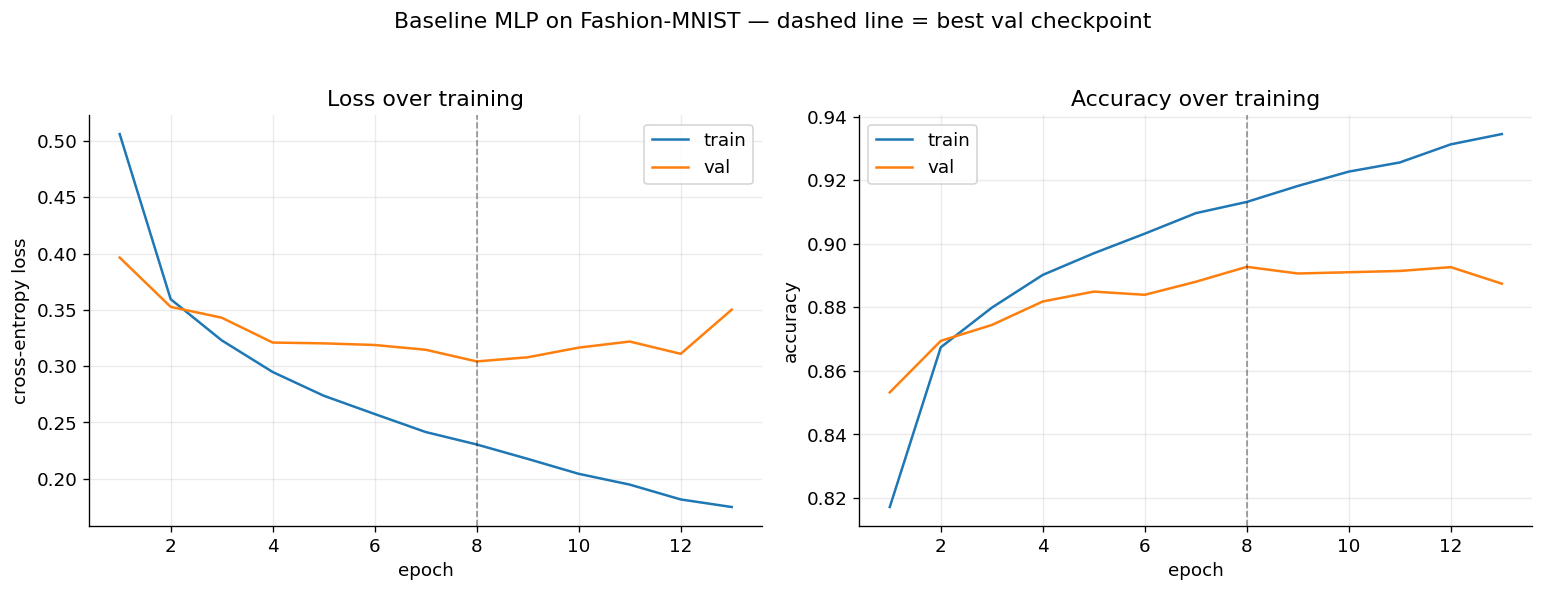

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.0))
axes[0].plot(history["epoch"], history["train_loss"], label="train")
axes[0].plot(history["epoch"], history["val_loss"],   label="val")
axes[0].axvline(best["epoch"], linestyle="--", linewidth=1, alpha=0.4, color="black")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("cross-entropy loss")
axes[0].set_title("Loss over training")
axes[0].legend(loc="best")

axes[1].plot(history["epoch"], history["train_acc"], label="train")
axes[1].plot(history["epoch"], history["val_acc"],   label="val")
axes[1].axvline(best["epoch"], linestyle="--", linewidth=1, alpha=0.4, color="black")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("accuracy")
axes[1].set_title("Accuracy over training")
axes[1].legend(loc="best")
fig.suptitle("Baseline MLP on Fashion-MNIST — dashed line = best val checkpoint")
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## Final test-set evaluation (touch the test set once)

Now — and only now — we evaluate the selected checkpoint on the held-out test set. If we wanted to tune anything (LR, hidden size, dropout, ...) we would go back, change it, and look at **validation** numbers. We do **not** read the test number, change something, and re-evaluate; that turns the test set into a second validation set.

Modern Fashion-MNIST baselines: a plain MLP typically lands around 87-90% test accuracy. A small CNN can push past 92%.

In [9]:
test_loss, test_acc = evaluate_loader(model, test_loader, nn.CrossEntropyLoss(), device)
print(f"Test loss:     {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")
print()
print(f"For comparison:")
print(f"  Best val loss: {best['val_loss']:.4f}")
print(f"  Best val acc:  {best['val_acc']:.4f}")

Test loss:     0.3342
Test accuracy: 0.8854

For comparison:
  Best val loss: 0.3041
  Best val acc:  0.8927


## Where do the errors concentrate?

A test accuracy number summarizes everything into one scalar. The **confusion matrix** breaks the same evaluation down by (true class, predicted class) and lets us see which classes the model is confusing. For Fashion-MNIST we typically expect to see confusion between visually similar categories — e.g. T-shirt / Shirt / Pullover / Coat — which a per-pixel MLP has no special tools to distinguish.

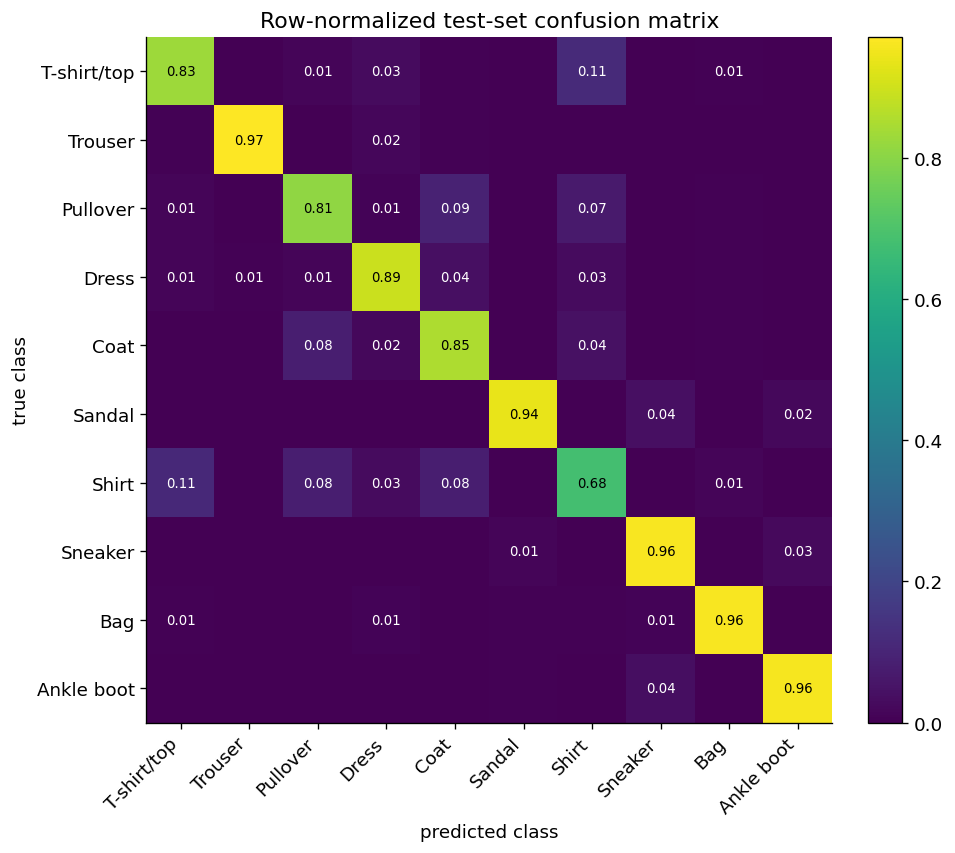

In [10]:
def confusion_matrix(model, loader, num_classes, device):
    cm = torch.zeros(num_classes, num_classes, dtype=torch.long)
    model.eval()
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb).argmax(-1)
            for t, p in zip(yb.cpu(), preds.cpu()):
                cm[t, p] += 1
    return cm

cm = confusion_matrix(model, test_loader, num_classes=10, device=device)
cm_row_norm = cm.float() / cm.sum(dim=1, keepdim=True).clamp_min(1)

fig, ax = plt.subplots(figsize=(8.5, 7.0), constrained_layout=True)
im = ax.imshow(cm_row_norm.numpy(), cmap="viridis")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel("predicted class")
ax.set_ylabel("true class")
ax.set_title("Row-normalized test-set confusion matrix")
ax.grid(False)
for i in range(10):
    for j in range(10):
        val = cm_row_norm[i, j].item()
        if val < 0.005:
            continue
        color = "white" if val < 0.5 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", color=color, fontsize=8)
plt.show()

## A look at misclassified test examples

Skimming a few specific failures often tells you more about the model than the aggregate accuracy. Below we pick a handful of test images the model got wrong, with the true label and the model's top guess.

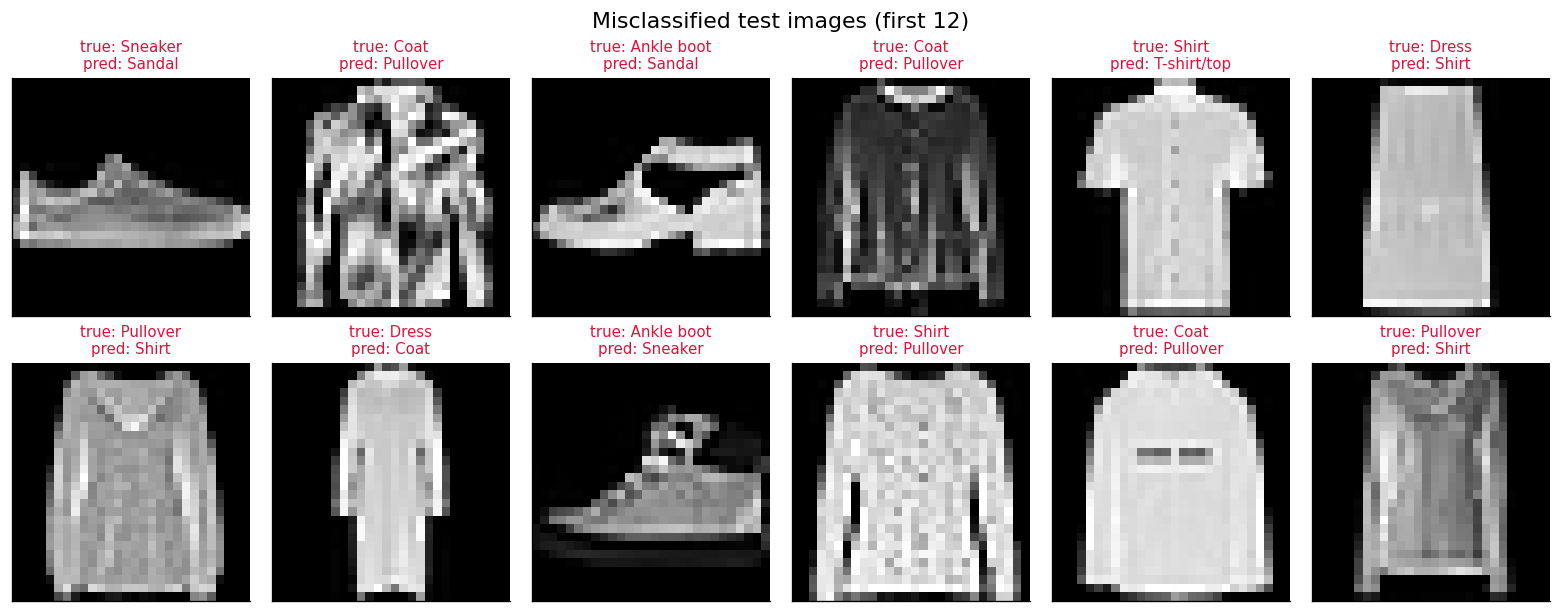

In [11]:
model.eval()
misclassified = []
with torch.no_grad():
    for xb, yb in test_loader:
        preds = model(xb.to(device)).argmax(-1).cpu()
        for img, true, pred in zip(xb, yb, preds):
            if pred.item() != true.item():
                misclassified.append((img, true.item(), pred.item()))
                if len(misclassified) >= 12:
                    break
        if len(misclassified) >= 12:
            break

fig, axes = plt.subplots(2, 6, figsize=(13, 5.0), constrained_layout=True)
for ax, (img, true, pred) in zip(axes.flat, misclassified):
    display_img = img[0].numpy() * FMNIST_STD[0] + FMNIST_MEAN[0]
    ax.imshow(display_img, cmap="gray")
    ax.set_title(f"true: {CLASS_NAMES[true]}\npred: {CLASS_NAMES[pred]}", fontsize=9, color="crimson")
    ax.set_xticks([]); ax.set_yticks([])
    ax.grid(False)
fig.suptitle("Misclassified test images (first 12)")
plt.show()

## Multi-seed confirmation

Following the discipline established in notebook 05 (and confirmed again in 06): a single-seed accuracy number can move by a percentage point or two between seeds. We retrain the baseline with two additional seeds and report mean +/- std across all three runs.

This is deliberately cheaper than the 5-6 seed sweeps from notebooks 05 and 06 — each Fashion-MNIST run is much more expensive than a ring-dataset run, so we cap it at three. You can raise `repeat_seeds` if you want tighter estimates.

In [12]:
repeat_seeds = [123, 234, 345]

val_losses, val_accs, test_accs = [], [], []
for ms in repeat_seeds:
    print(f"\n=== seed {ms} ===")
    m, h, b = train_with_loaders(
        adamw_factory(lr=1e-3),
        train_loader, val_loader,
        max_epochs=30, patience=5,
        model_seed=ms,
        verbose=False,
    )
    t_loss, t_acc = evaluate_loader(m, test_loader, nn.CrossEntropyLoss(), device)
    val_losses.append(b["val_loss"])
    val_accs.append(b["val_acc"])
    test_accs.append(t_acc)
    print(f"  best val loss {b['val_loss']:.4f}, val acc {b['val_acc']:.4f}, test acc {t_acc:.4f} (best epoch {b['epoch']})")

print()
print(f"val loss across seeds:     {np.mean(val_losses):.4f} +/- {np.std(val_losses):.4f}")
print(f"val accuracy across seeds: {np.mean(val_accs):.4f} +/- {np.std(val_accs):.4f}")
print(f"test accuracy across seeds:{np.mean(test_accs):.4f} +/- {np.std(test_accs):.4f}")


=== seed 123 ===
  best val loss 0.3005, val acc 0.8926, test acc 0.8864 (best epoch 6)

=== seed 234 ===
  best val loss 0.3035, val acc 0.8953, test acc 0.8859 (best epoch 8)

=== seed 345 ===
  best val loss 0.3048, val acc 0.8903, test acc 0.8787 (best epoch 7)

val loss across seeds:     0.3029 +/- 0.0018
val accuracy across seeds: 0.8927 +/- 0.0020
test accuracy across seeds:0.8837 +/- 0.0035


## Summary

What changed going from the synthetic ring data to Fashion-MNIST:

| Change                | Why                                                                              |
|-----------------------|----------------------------------------------------------------------------------|
| `Dataset` + `DataLoader` | Real data lives on disk; we batch and shuffle through the loader, not by hand. |
| Three-way split       | Test set is held out so the final accuracy is an unbiased estimate.              |
| Input normalization   | Optimizer sees inputs with roughly mean 0 / unit variance.                       |
| ReLU instead of Tanh  | Better for deeper / wider fully-connected layers.                                |
| Cross-entropy loss    | 10-class classification; expects raw logits, not softmax.                        |
| `device` placement    | GPU/MPS makes real-data training tractable.                                      |

What stayed the same — and is the point:

- early stopping on validation loss with restoration of the best checkpoint,
- model selection on validation, then a single touch of the test set,
- multi-seed confirmation of the headline number.

An MLP gets roughly 88-89% test accuracy on Fashion-MNIST. The confusion matrix shows where it struggles: the visually similar top-half garments (Shirt / T-shirt / Pullover / Coat) bleed into each other. A plain MLP throws away spatial structure (it flattens the image first), so it has no special tools for that kind of confusion. **Convolutional networks**, which preserve and exploit that spatial structure, are the natural next step.

## Exercises

1. **Skip normalization.** Drop the `transforms.Normalize` step so inputs stay in `[0, 1]`. How much does the final test accuracy change? How much does training stability change at higher LRs?

2. **Hidden size sweep.** Try `hidden=(128,)`, `hidden=(256, 128)` (default), and `hidden=(512, 256, 128)`. Where does adding capacity stop helping?

3. **Dropout.** Add `nn.Dropout(p=0.2)` between the hidden layers. Does it lower the train/val gap? Does it help test accuracy?

4. **Optimizer.** Swap AdamW for SGD+momentum (`lr=0.05`, `momentum=0.9`). Add a cosine LR schedule. Can you match AdamW's accuracy?

5. **Test-set discipline.** Deliberately tune the LR by checking the **test** number after each run, and again by checking only the **validation** number. Are the two procedures meaningfully different here, with a fixed seed and a well-behaved dataset?

6. **Save and reload.** Use `torch.save(model.state_dict(), "model.pt")` and `model.load_state_dict(torch.load("model.pt"))` to persist the trained model. Verify the reloaded model produces identical predictions.